# **1.Mounting Google Drive**

In [9]:
#Untuk mengkoneksikan Google Colab dengan Folder Google Drive
from google.colab import drive
#Untuk memulai proses mounting dari google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2.Load Data**

In [8]:
#Melakukan import library os untuk membuat dan menghapus direktori, mengambil isi direktori, dll
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
#Mendefinisikan variabel untuk menyimpan lokasi folder citra di dalam Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/Citra_Pohon'

#Untuk mengubah direktori sesuai dengan nilai variabel folder_path
os.chdir(folder_path)

#Melakukan perulangan dengan kondisi akhir sesuai jumlah isi file di dalam folder
for file_name in os.listdir(folder_path):
    #Mencetak pesan nama file yang ada di dalam folder
    print(f"Nama File: {file_name}")

Nama File: 1.jpg
Nama File: 0.jpg
Nama File: 14.jpg
Nama File: 13.jpg
Nama File: 12.jpg
Nama File: 11.jpg
Nama File: 10.jpg
Nama File: 19.jpg
Nama File: 18.jpg
Nama File: 17.jpg
Nama File: 16.jpg
Nama File: 15.jpg
Nama File: 22.jpg
Nama File: 21.jpg
Nama File: 20.jpg
Nama File: 2.jpg
Nama File: 5.jpg
Nama File: 4.jpg
Nama File: 3.jpg
Nama File: 25.jpg
Nama File: 24.jpg
Nama File: 23.jpg
Nama File: 9.jpg
Nama File: 8.jpg
Nama File: 7.jpg
Nama File: 6.jpg
Nama File: grayscale_1.jpg
Nama File: grayscale_0.jpg
Nama File: grayscale_14.jpg
Nama File: grayscale_13.jpg
Nama File: grayscale_12.jpg
Nama File: grayscale_11.jpg
Nama File: grayscale_10.jpg
Nama File: grayscale_19.jpg
Nama File: grayscale_18.jpg
Nama File: grayscale_17.jpg
Nama File: grayscale_16.jpg
Nama File: grayscale_15.jpg
Nama File: grayscale_22.jpg
Nama File: grayscale_21.jpg
Nama File: grayscale_20.jpg
Nama File: grayscale_2.jpg
Nama File: grayscale_5.jpg
Nama File: grayscale_4.jpg
Nama File: grayscale_3.jpg
Nama File: grays

# **3. Melakukan Konversi Citra BGR ke Grayscale**

In [12]:
#Melakukan import library opencv yang digunakan untuk melakukan konversi color space
import cv2

#Mendefinisikan variabel untuk menyimpan lokasi folder citra di dalam Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/Citra_Pohon'

#Melakukan perulangan dengan kondisi akhir sesuai jumlah isi file di dalam folder
for file_name in os.listdir(folder_path):
    #Menentukan spesifikasi file citra yang akan digunakan, yaitu yang memiliki ekstensi.jpg, .jpeg, dan .png
    if file_name.endswith('.jpg') or file_name.endswith('.jpeg') or file_name.endswith('.png'):
        #Membaca file citra yang ada di dalam folder Google Drive
        image = cv2.imread(os.path.join(folder_path, file_name))
        #Melakukan konversi citra dari BGR menjadi Grayscale
        grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        #Menyimpan dan mendefinisikan nama file citra hasil konversi ke dalam folder Google Drive
        cv2.imwrite(os.path.join(folder_path, f"grayscale_{file_name}"), grayscale_image)
        #Mencetak pesan berhasil mengkonversi citra
        print(f'File {file_name} berhasil diubah menjadi grayscale.')

File 1.jpg berhasil diubah menjadi grayscale.
File 0.jpg berhasil diubah menjadi grayscale.
File 14.jpg berhasil diubah menjadi grayscale.
File 13.jpg berhasil diubah menjadi grayscale.
File 12.jpg berhasil diubah menjadi grayscale.
File 11.jpg berhasil diubah menjadi grayscale.
File 10.jpg berhasil diubah menjadi grayscale.
File 19.jpg berhasil diubah menjadi grayscale.
File 18.jpg berhasil diubah menjadi grayscale.
File 17.jpg berhasil diubah menjadi grayscale.
File 16.jpg berhasil diubah menjadi grayscale.
File 15.jpg berhasil diubah menjadi grayscale.
File 22.jpg berhasil diubah menjadi grayscale.
File 21.jpg berhasil diubah menjadi grayscale.
File 20.jpg berhasil diubah menjadi grayscale.
File 2.jpg berhasil diubah menjadi grayscale.
File 5.jpg berhasil diubah menjadi grayscale.
File 4.jpg berhasil diubah menjadi grayscale.
File 3.jpg berhasil diubah menjadi grayscale.
File 25.jpg berhasil diubah menjadi grayscale.
File 24.jpg berhasil diubah menjadi grayscale.
File 23.jpg berhasi

# **4. Melakukan Ekstraksi Fitur Tekstur pada 10 Citra**

In [13]:
#Melakukan import library os untuk membuat dan menghapus direktori, mengambil isi direktori, dll
import os
#Melakukan import library opencv yang digunakan untuk melakukan konversi color space
import cv2
#Melakukan import library NumPy yang digunakan untuk membentuk objek N-dimensional array
import numpy as np
#Melakukan import graycomatrix untuk menghitung matriks co-occurance tingkat keabuan, dan graycoprops untuk menghitung properti tekstur dari GLCM dari library skimage.feature
from skimage.feature import graycomatrix, graycoprops
#Melakukan import library Pandas yang digunakan untuk membaca isi file excel
import pandas as pd

#Mendefinisikan variabel untuk menyimpan lokasi folder citra di dalam Google Drive
folder_path = '/content/drive/MyDrive/Colab Notebooks/Citra_Pohon'
#Membuat variabel array kosong yang akan digunakan untuk menampung nilai fitur hasil ekstraksi
nilai_fitur = []

#Melakukan perulangan dengan kondisi akhir sesuai jumlah isi file di dalam folder
for file_name in os.listdir(folder_path):
    #Menentukan spesifikasi file citra yang akan digunakan, yaitu yang memiliki ekstensi.jpg, .jpeg, dan .png
    if file_name.endswith(".jpg") or file_name.endswith('.jpeg') or file_name.endswith(".png"):
        #Membaca file citra yang ada di dalam folder Google Drive
        image = cv2.imread(os.path.join(folder_path, file_name))
        #Melakukan konversi citra dari BGR menjadi Grayscale
        grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        #Menghitung matriks co-occurance dari citra hasil konversi
        glcm = graycomatrix(grayscale_image, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
        #Menghitung rata-rata properti tekstur energi dari GLCM
        energi = graycoprops(glcm, 'energy').mean()
        #Menghitung rata-rata properti tekstur kontras dari GLCM
        kontras = graycoprops(glcm, 'contrast').mean()
        #Menghitung rata-rata properti tekstur korelasi dari GLCM
        korelasi = graycoprops(glcm, 'correlation').mean()
        #Menghitung rata-rata properti tekstur homogenitas dari GLCM
        homogenitas = graycoprops(glcm, 'homogeneity').mean()
        #Menampung nilai fitur ke dalam variabel array nilai_fitur
        nilai_fitur.append([file_name, energi, kontras, korelasi, homogenitas])

        #Mencetak nama file
        print(f"File {file_name}:")
        #Mencetak nilai energi
        print(f"Energi: {energi:.3f}")
        #Mencetak nilai kontras
        print(f"Kontras: {kontras:.3f}")
        #Mencetak nilai korelasi
        print(f"Korelasi: {korelasi:.3f}")
        #Mencetak nilai homogenitas
        print(f"Homogenitas: {homogenitas:.3f}")
    else:
        #Mencetak nama file jika bukan gambar
        print(f"Nama File: {file_name}")

File 1.jpg:
Energi: 0.052
Kontras: 5.574
Korelasi: 0.988
Homogenitas: 0.449
File 0.jpg:
Energi: 0.048
Kontras: 5.228
Korelasi: 0.993
Homogenitas: 0.461
File 14.jpg:
Energi: 0.045
Kontras: 5.865
Korelasi: 0.992
Homogenitas: 0.451
File 13.jpg:
Energi: 0.046
Kontras: 5.479
Korelasi: 0.992
Homogenitas: 0.452
File 12.jpg:
Energi: 0.037
Kontras: 11.514
Korelasi: 0.988
Homogenitas: 0.377
File 11.jpg:
Energi: 0.055
Kontras: 2.892
Korelasi: 0.996
Homogenitas: 0.532
File 10.jpg:
Energi: 0.058
Kontras: 4.266
Korelasi: 0.989
Homogenitas: 0.489
File 19.jpg:
Energi: 0.033
Kontras: 5.782
Korelasi: 0.998
Homogenitas: 0.466
File 18.jpg:
Energi: 0.033
Kontras: 5.636
Korelasi: 0.998
Homogenitas: 0.471
File 17.jpg:
Energi: 0.038
Kontras: 7.256
Korelasi: 0.999
Homogenitas: 0.445
File 16.jpg:
Energi: 0.029
Kontras: 8.740
Korelasi: 0.997
Homogenitas: 0.413
File 15.jpg:
Energi: 0.056
Kontras: 3.402
Korelasi: 0.993
Homogenitas: 0.519
File 22.jpg:
Energi: 0.028
Kontras: 6.225
Korelasi: 0.999
Homogenitas: 0.486


# **5. Melakukan Penampungan Nilai-Nilai Fitur ke dalam File .xlsx dan Membuka isi File .xlsx**

In [14]:
#Mendefinisikan variabel untuk menyimpan nama kolom pada excel
nama_kolom = ['Nama File', 'Energi', 'Kontras', 'Korelasi', 'Homogenitas']
#Menyimpan nilai-nilai hasil ekstraksi fitur ke dalam dataframe
fitur_dataframe = pd.DataFrame(nilai_fitur, columns=nama_kolom)

#Mendefinisikan variabel untuk menyimpan nama dan ekstensi file
nama_file = '2318122_HasilEkstraksiFitur.xlsx'
#Menyimpan dataframe ke dalam file excel dengan nama sesuai dengan variabel nama_file
fitur_dataframe.to_excel(nama_file, index=False)

#Mencetak pesan bahwa file berhasil disimpan
print(f'File {nama_file} Berhasil Disimpan.')

#Membaca file excel yang sudah dibuat
excel = pd.read_excel('2318122_HasilEkstraksiFitur.xlsx')

#Mencetak isi dari file excel
print(excel)

File 2318122_HasilEkstraksiFitur.xlsx Berhasil Disimpan.
                     Nama File    Energi    Kontras  Korelasi  Homogenitas
0                        1.jpg  0.051788   5.573662  0.988074     0.448564
1                        0.jpg  0.048114   5.228350  0.992835     0.460938
2                       14.jpg  0.045403   5.865210  0.992192     0.450838
3                       13.jpg  0.045880   5.479082  0.992462     0.451761
4                       12.jpg  0.036599  11.513843  0.988084     0.377146
..                         ...       ...        ...       ...          ...
73  grayscale_grayscale_23.jpg  0.025762  13.859434  0.997008     0.409914
74   grayscale_grayscale_9.jpg  0.031577   6.008099  0.998323     0.454284
75   grayscale_grayscale_8.jpg  0.028096   8.272964  0.997954     0.435383
76   grayscale_grayscale_7.jpg  0.034646   7.099722  0.997126     0.457363
77   grayscale_grayscale_6.jpg  0.027310  16.552567  0.994355     0.373325

[78 rows x 5 columns]


# **6.Histogram Pesebarana Fitur**

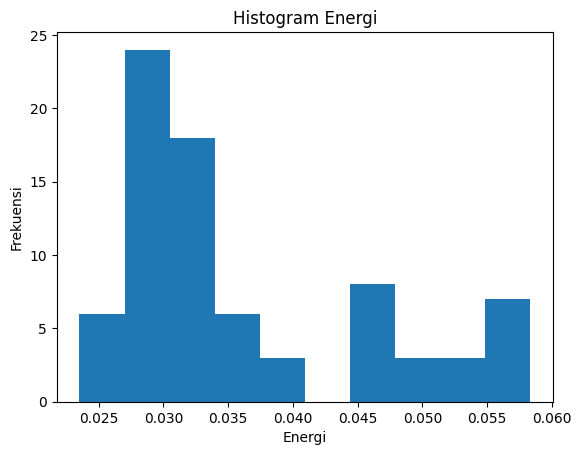

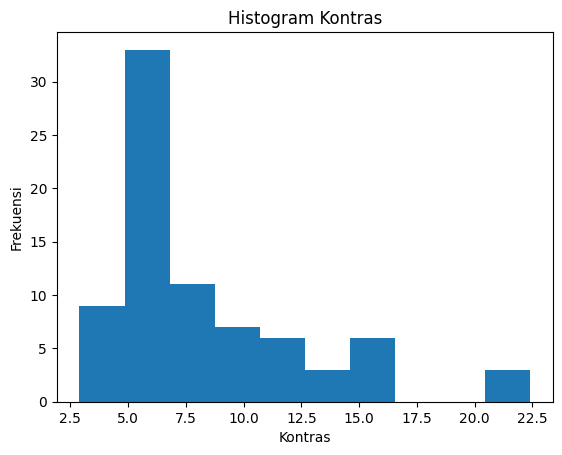

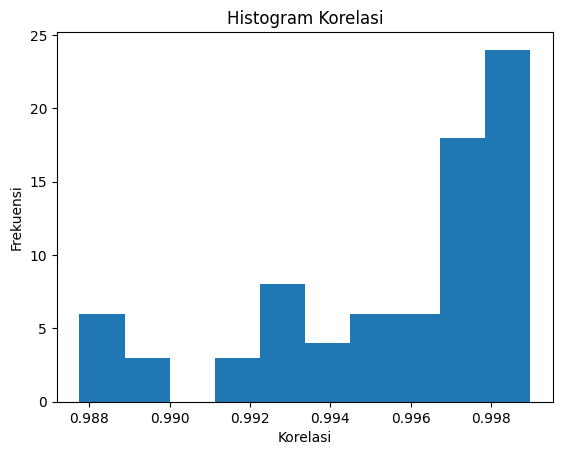

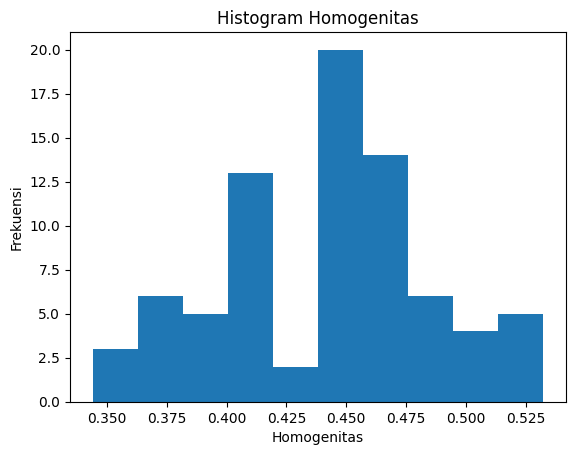

In [16]:
# Histogram Energi
plt.figure()
plt.hist(fitur_dataframe['Energi'], bins=10)
plt.title('Histogram Energi')
plt.xlabel('Energi')
plt.ylabel('Frekuensi')
plt.show()

# Histogram Kontras
plt.figure()
plt.hist(fitur_dataframe['Kontras'], bins=10)
plt.title('Histogram Kontras')
plt.xlabel('Kontras')
plt.ylabel('Frekuensi')
plt.show()

# Histogram Korelasi
plt.figure()
plt.hist(fitur_dataframe['Korelasi'], bins=10)
plt.title('Histogram Korelasi')
plt.xlabel('Korelasi')
plt.ylabel('Frekuensi')
plt.show()

# Histogram Homogenitas
plt.figure()
plt.hist(fitur_dataframe['Homogenitas'], bins=10)
plt.title('Histogram Homogenitas')
plt.xlabel('Homogenitas')
plt.ylabel('Frekuensi')
plt.show()